# Survival Analysis Project - Tree Survival Prediction

Our goal is to analyze which tree seeds survive the season.

> [Tree Survival Dataset on Kaggle](https://www.kaggle.com/datasets/yekenot/tree-survival-prediction)

### By Jiří Liška & Pacioga Eduard-Andrei

## Imports

In [1]:
import kagglehub

import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

import lifelines

/home/jl/Uni/erasmus_Madrid/APPR/appr_project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Tree Data


In [2]:
path = kagglehub.dataset_download("yekenot/tree-survival-prediction")

print("Path to dataset files:", path)

Path to dataset files: /home/jl/.cache/kagglehub/datasets/yekenot/tree-survival-prediction/versions/1


In [3]:
# provide a type schema for the dataset
data_schema = {
    "No": pl.Int32,
    "Plot": pl.Int32,
    "Subplot": pl.Categorical,
    "Species": pl.Categorical,
    "Light_ISF": pl.Float32,
    "Light_Cat": pl.Categorical,
    "Core": pl.Int32,
    "Soil": pl.Categorical,
    "Adult": pl.Categorical,
    "Sterile": pl.Categorical,
    "Conspecific": pl.Categorical,
    "Myco": pl.Categorical,
    "SoilMyco": pl.Categorical,
    # "PlantDate": pl.Date,
    "AMF": pl.Float32,
    "EMF": pl.Float32,
    "Phenolics": pl.Float32,
    "Lignin": pl.Float32,
    "NSC": pl.Float32,
    "Census": pl.Int32,
    "Time": pl.Float32,
    # "Event": pl.Boolean,
    # "Harvest": pl.Boolean,
    # "Alive": pl.Boolean,
}

In [4]:
raw_df = pl.read_csv(
    f"{path}/Tree_Data.csv",
    schema_overrides=data_schema,
    null_values=["NA"],
)

raw_df.head()

No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
i32,i32,cat,cat,f32,cat,i32,cat,cat,cat,cat,cat,cat,str,f32,f32,f32,f32,f32,i32,f32,i64,str,str
126,1,"""C""","""Acer saccharum""",0.106,"""Med""",2017,"""Prunus serotina""","""I""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""","""6/11/18""",22.0,null,-0.56,13.86,12.15,4,14.0,1,null,null
11,1,"""C""","""Quercus alba""",0.106,"""Med""",2017,"""Quercus rubra""","""970""","""Non-Sterile""","""Heterospecific""","""EMF""","""EMF""","""5/25/18""",15.82,31.07,5.19,20.52,19.290001,33,115.5,0,null,"""X"""
12,1,"""C""","""Quercus rubra""",0.106,"""Med""",2017,"""Prunus serotina""","""J""","""Non-Sterile""","""Heterospecific""","""EMF""","""AMF""","""5/31/18""",24.450001,28.190001,3.36,24.74,15.01,18,63.0,1,null,null
2823,7,"""D""","""Acer saccharum""",0.08,"""Med""",2016,"""Prunus serotina""","""J""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""","""6/11/18""",22.23,null,-0.71,14.29,12.36,4,14.0,1,null,null
5679,14,"""A""","""Acer saccharum""",0.06,"""Low""",2017,"""Prunus serotina""","""689""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""","""6/11/18""",21.15,null,-0.58,10.85,11.2,4,14.0,1,null,null


In [5]:
def clean_dataset(df: pl.DataFrame) -> pl.DataFrame:
    return (
        df
        # only 1 row with event is null, so remove it
        .filter(pl.col("Event").is_not_null())
        # parse dates in PlantDate column ("6/11/18")
        .with_columns(pl.col("PlantDate").str.strptime(pl.Date, "%m/%d/%y"))
        # For "Harvest" and "Alive": "X" -> True, else False
        .with_columns(
            (pl.col("Harvest") == "X").fill_null(False).alias("Harvest"),
            (pl.col("Alive") == "X").fill_null(False).alias("Alive"),
        )
        .with_columns(
            # cast Event to boolean (True if 1 (Dead), False if 0 (Alive/end of study))
            (pl.col("Event") == 1).alias("Event")
        )
    )


In [6]:
df = clean_dataset(raw_df)

In [7]:
df.head()

No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
i32,i32,cat,cat,f32,cat,i32,cat,cat,cat,cat,cat,cat,date,f32,f32,f32,f32,f32,i32,f32,bool,bool,bool
126,1,"""C""","""Acer saccharum""",0.106,"""Med""",2017,"""Prunus serotina""","""I""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""",2018-06-11,22.0,null,-0.56,13.86,12.15,4,14.0,true,false,false
11,1,"""C""","""Quercus alba""",0.106,"""Med""",2017,"""Quercus rubra""","""970""","""Non-Sterile""","""Heterospecific""","""EMF""","""EMF""",2018-05-25,15.82,31.07,5.19,20.52,19.290001,33,115.5,false,false,true
12,1,"""C""","""Quercus rubra""",0.106,"""Med""",2017,"""Prunus serotina""","""J""","""Non-Sterile""","""Heterospecific""","""EMF""","""AMF""",2018-05-31,24.450001,28.190001,3.36,24.74,15.01,18,63.0,true,false,false
2823,7,"""D""","""Acer saccharum""",0.08,"""Med""",2016,"""Prunus serotina""","""J""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""",2018-06-11,22.23,null,-0.71,14.29,12.36,4,14.0,true,false,false
5679,14,"""A""","""Acer saccharum""",0.06,"""Low""",2017,"""Prunus serotina""","""689""","""Non-Sterile""","""Heterospecific""","""AMF""","""AMF""",2018-06-11,21.15,null,-0.58,10.85,11.2,4,14.0,true,false,false


## EDA

### Data specification:

Source: Kaggle website

- No: Seedling unique ID number.
- Plot: Number of the field plot the seedling was planted in (1-18).
- Subplot: Subplot within the main plot the seedling was planted in. Broken into 5 subplots (1 per corner, plus 1 in the middle) (A-E).
- Species: Includes Acer saccharum, Prunus serotina, Quercus alba, and Quercus rubra.
- Light ISF: Light level quantified with HemiView software. Represents the amount of light reaching each subplot at a height of 1m.
- Light Cat: Categorical light level created by splitting the range of Light_ISF values into three bins (low, med, high).
- Core: Year the soil core was removed from the field.
- Soil: Species from which the soil core was taken. Includes all species, plus Acer rubrum, Populus grandidentata, and a sterilized conspecific for each species.
- Adult: Individual tree that soil was taken from. Up to 6 adults per species. Used as a random effect in analyses.
- Sterile: Whether the soil was sterilized or not.
- Conspecific: Whether the soil was conspecific, heterospecific, or sterilized conspecific.
- Myco: Mycorrhizal type of the seedling species (AMF or EMF).
- SoilMyco: Mycorrhizal type of the species culturing the soil (AMF or EMF).
- PlantDate: The date that seedlings were planted in the field pots.
- AMF: Percent arbuscular mycorrhizal fungi colonization on the fine roots of harvested seedlings.
- EMF: Percent ectomycorrhizal fungi colonization on the root tips of harvested seedlings.
- Phenolics: Calculated as nmol Gallic acid equivalents per mg dry extract (see manuscript for detailed methods).
- NSC: Calculated as percent dry mass nonstructural carbohydrates (see manuscript for detailed methods).
- Lignin: Calculated as percent dry mass lignin (see manuscript for detailed methods).
- Census: The census number at which time the seedling died or was harvested.
- Time: The number of days at which time the seedling died or was harvested.
- Event: Used for survival analysis to indicate status of each individual seedling at a given time (above)
    - 0 = harvested or experiment ended
    - 1 = dead
- Harvest: Indicates whether the seedling was harvested for trait measurement.
- Alive: Indicates if the seedling was alive at the end of the second growing season. "X" in this field indicates alive status.

Missing data is coded as NA.

### Dataset summary statistics

In [8]:
df.describe()

statistic,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
str,f64,f64,str,str,f64,str,f64,str,str,str,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",2782.0,2782.0,"""2782""","""2782""",2782.0,"""2782""",2782.0,"""2782""","""2782""","""2782""","""2782""","""2782""","""2782""","""2782""",2782.0,1282.0,2782.0,2782.0,2782.0,2782.0,2782.0,2782.0,2782.0,2782.0
"""null_count""",0.0,0.0,"""0""","""0""",0.0,"""0""",0.0,"""0""","""0""","""0""","""0""","""0""","""0""","""0""",0.0,1500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",3913.127606,9.558591,null,null,0.08568,null,2016.648814,null,null,null,null,null,null,"""2018-05-31 10:44:56.764917""",20.55435,26.479843,1.932261,15.758491,14.217074,15.275701,53.464954,0.570453,0.253055,0.176492
"""std""",2252.733097,5.202133,null,null,0.025603,null,0.477427,null,null,null,null,null,null,null,12.311615,16.643013,1.969693,6.780478,4.29691,9.162042,32.067146,null,null,null
"""min""",3.0,1.0,null,null,0.032,null,2016.0,null,null,null,null,null,null,"""2018-05-10""",0.0,0.0,-1.35,2.23,4.3,4.0,14.0,0.0,0.0,0.0
"""25%""",1970.0,5.0,null,null,0.066,null,2016.0,null,null,null,null,null,null,"""2018-05-25""",13.4,13.78,0.17,10.35,11.6,7.0,24.5,null,null,null
"""50%""",3932.0,10.0,null,null,0.082,null,2017.0,null,null,null,null,null,null,"""2018-06-01""",18.0,27.74,0.75,14.04,12.66,13.0,45.5,null,null,null
"""75%""",5878.0,14.0,null,null,0.1,null,2017.0,null,null,null,null,null,null,"""2018-06-06""",24.450001,35.709999,3.78,21.120001,17.27,18.0,63.0,null,null,null
"""max""",7772.0,18.0,null,null,0.161,null,2017.0,null,null,null,null,null,null,"""2018-06-15""",100.0,87.5,6.1,32.77,29.450001,33.0,115.5,1.0,1.0,1.0


In [9]:
# print percentage of missing values in each column
missing_values = df.null_count()
print("Number of missing values in each column:")

missing_values

Number of missing values in each column:


No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1500,0,0,0,0,0,0,0,0


The only column with missing values is EMF, so we replace it with the mean of the column.

In [10]:
df = df.with_columns(pl.col("EMF").fill_null(pl.col("EMF").mean()))

## Visualizations

Histograms & box plots for key numerical features and bar plots for categorical features to visualize their distributions.

### Numerical columns

In [11]:
import polars.selectors as cs

# Set plot style
sns.set_style("whitegrid")

# Select only numerical columns for plotting
numerical_cols = df.select(cs.numeric()).columns
print("Numerical columns:", numerical_cols)

n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Numerical columns: ['No', 'Plot', 'Light_ISF', 'Core', 'AMF', 'EMF', 'Phenolics', 'Lignin', 'NSC', 'Census', 'Time']


NameError: name 'math' is not defined

### Categorical/Boolean columns

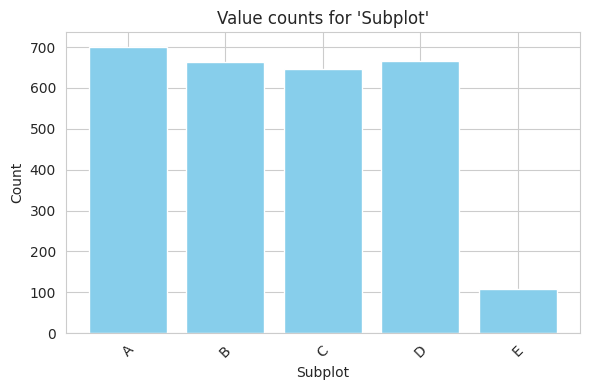

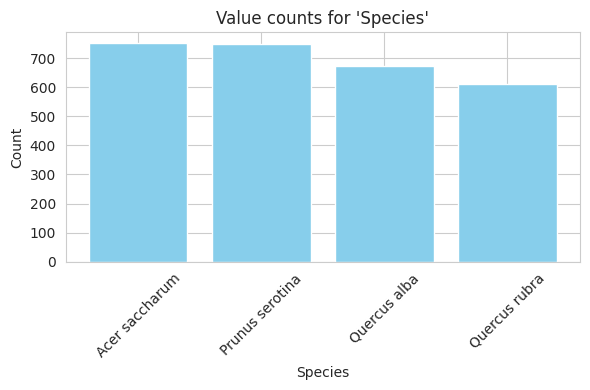

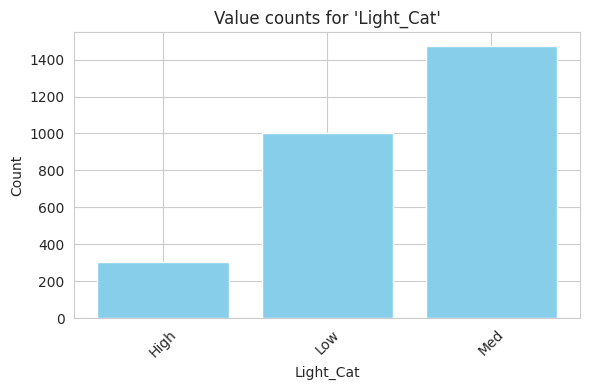

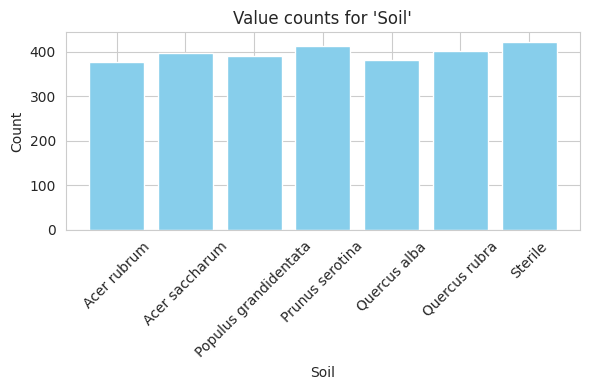

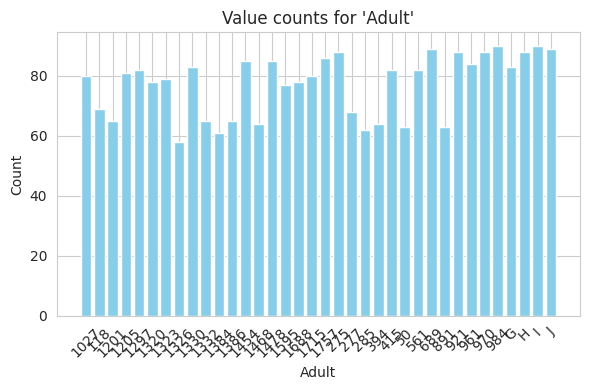

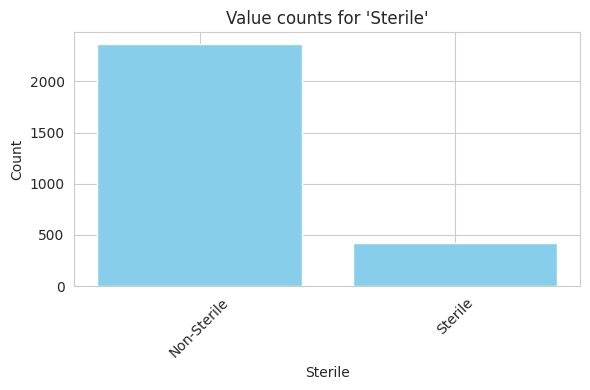

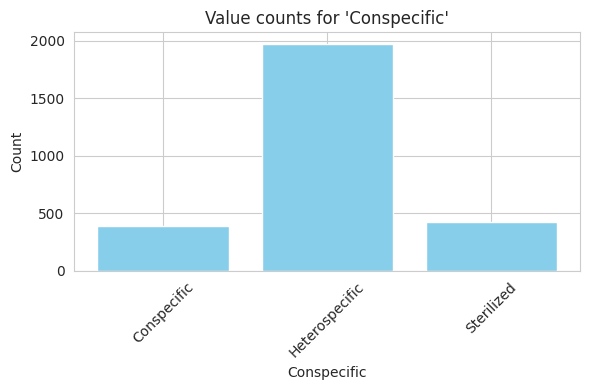

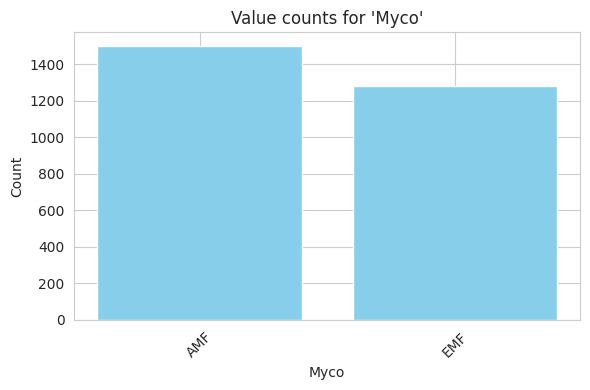

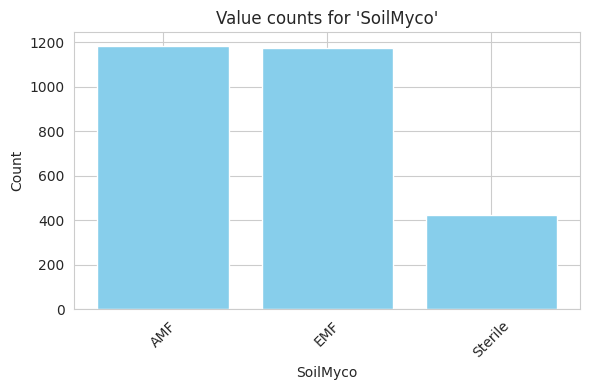

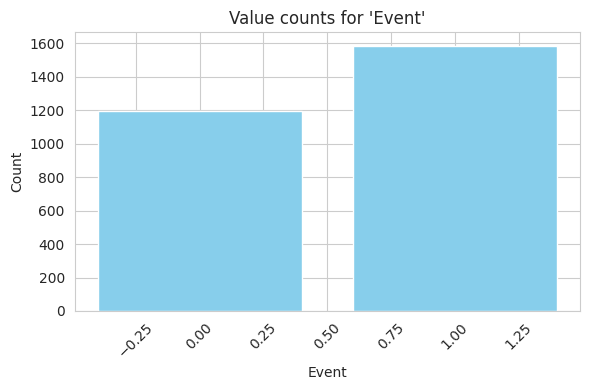

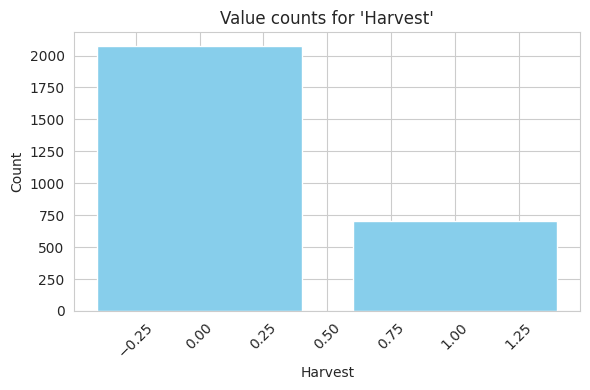

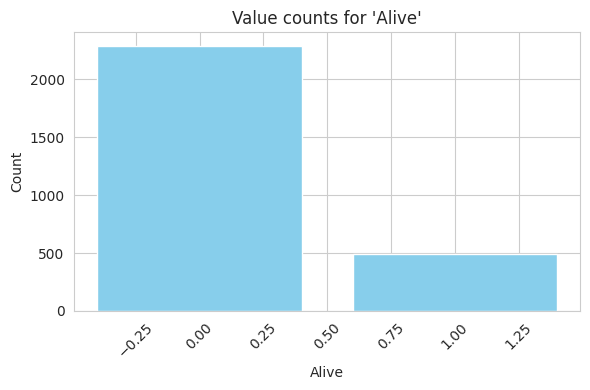

In [ ]:
# Bar plots for Cateoricals and Booleans

cat_bool_cols = df.select(cs.categorical() | cs.boolean()).columns

for col in cat_bool_cols:
    # Modern Polars: use value_counts + sort
    counts = df.select(pl.col(col).value_counts().sort()).unnest(col)

    # Extract keys and values for plotting
    keys = counts[col].to_list()
    values = counts["count"].to_list()

    # Plot
    plt.figure(figsize=(6, 4))
    plt.bar(keys, values, color="skyblue")
    plt.title(f"Value counts for '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Clarification of 'Time' and 'Event'

Based on the dataset metadata, the columns 'Time' and 'Event' are defined as follows:

*   **Time**: Represents the number of days at which the seedling died or was harvested.
*   **Event**: Used for survival analysis to indicate the status of each individual seedling at a given time.
    *   `0`: Seedling was harvested or the experiment ended (censored event).
    *   `1`: Seedling died (event of interest).

# Task
The next step is to prepare the `df_final` DataFrame for machine learning models by converting categorical features into a numerical format. This involves identifying all `object` type columns and applying one-hot encoding. This process ensures that all variables are in a suitable format for subsequent analysis and model development.

To do this, I'll first identify all columns with `object` data types. Then, I'll apply `pd.get_dummies` to these columns, creating new binary columns for each unique category. Finally, I'll concatenate these new columns with the original numerical columns and drop the original categorical columns, resulting in a fully numerical DataFrame.

## Impute Categorical Features

Convert categorical features into a numerical format using one-hot encoding.


In [65]:
df_final = df.to_pandas()

In [66]:
df_final.dtypes

No                      int32
Plot                    int32
Subplot              category
Species              category
Light_ISF             float32
Light_Cat            category
Core                    int32
Soil                 category
Adult                category
Sterile              category
Conspecific          category
Myco                 category
SoilMyco             category
PlantDate      datetime64[ms]
AMF                   float32
EMF                   float32
Phenolics             float32
Lignin                float32
NSC                   float32
Census                  int32
Time                  float32
Event                    bool
Harvest                  bool
Alive                    bool
dtype: object

In [67]:
categorical_cols = df_final.select_dtypes(include="category").columns.tolist()
print(f"Identified categorical columns: {categorical_cols}")

# 2. Apply one-hot encoding to these identified categorical columns.
df_encoded = pd.get_dummies(
    df_final[categorical_cols], drop_first=True
)  # drop_first to avoid multicollinearity

# 3. Concatenate the original df_final with the new dummy variables DataFrame and drop original categorical columns.
df_final = pd.concat([df_final.drop(columns=categorical_cols), df_encoded], axis=1)

print("\nDataFrame after one-hot encoding:")
print(df_final.head())
print("\nInfo of the modified DataFrame:")
df_final.info()

Identified categorical columns: ['Subplot', 'Species', 'Light_Cat', 'Soil', 'Adult', 'Sterile', 'Conspecific', 'Myco', 'SoilMyco']

DataFrame after one-hot encoding:
     No  Plot  Light_ISF  Core  PlantDate        AMF        EMF  Phenolics  \
0   126     1      0.106  2017 2018-06-11  22.000000  26.479843      -0.56   
1    11     1      0.106  2017 2018-05-25  15.820000  31.070000       5.19   
2    12     1      0.106  2017 2018-05-31  24.450001  28.190001       3.36   
3  2823     7      0.080  2016 2018-06-11  22.230000  26.479843      -0.71   
4  5679    14      0.060  2017 2018-06-11  21.150000  26.479843      -0.58   

   Lignin        NSC  ...  Adult_1326  Adult_H  Adult_1027  Adult_G  \
0   13.86  12.150000  ...       False    False       False    False   
1   20.52  19.290001  ...       False    False       False    False   
2   24.74  15.010000  ...       False    False       False    False   
3   14.29  12.360000  ...       False    False       False    False   
4   10.85 

In [68]:
df_final.columns

Index(['No', 'Plot', 'Light_ISF', 'Core', 'PlantDate', 'AMF', 'EMF',
       'Phenolics', 'Lignin', 'NSC', 'Census', 'Time', 'Event', 'Harvest',
       'Alive', 'Subplot_D', 'Subplot_A', 'Subplot_B', 'Subplot_E',
       'Species_Quercus alba', 'Species_Quercus rubra',
       'Species_Prunus serotina', 'Light_Cat_Low', 'Light_Cat_High',
       'Soil_Quercus rubra', 'Soil_Acer rubrum', 'Soil_Populus grandidentata',
       'Soil_Sterile', 'Soil_Acer saccharum', 'Soil_Quercus alba', 'Adult_970',
       'Adult_J', 'Adult_689', 'Adult_1332', 'Adult_891', 'Adult_1595',
       'Adult_1323', 'Adult_394', 'Adult_561', 'Adult_1478', 'Adult_1320',
       'Adult_1454', 'Adult_921', 'Adult_984', 'Adult_118', 'Adult_1757',
       'Adult_1384', 'Adult_1688', 'Adult_961', 'Adult_1715', 'Adult_50',
       'Adult_1468', 'Adult_1201', 'Adult_1386', 'Adult_277', 'Adult_415',
       'Adult_285', 'Adult_275', 'Adult_1205', 'Adult_1330', 'Adult_1297',
       'Adult_1326', 'Adult_H', 'Adult_1027', 'Adult_G', 'S

## Plot Kaplan-Meier Survival Curve

Generate and display a Kaplan-Meier survival curve using the 'Time' and 'Event' columns from the `df_final` DataFrame.


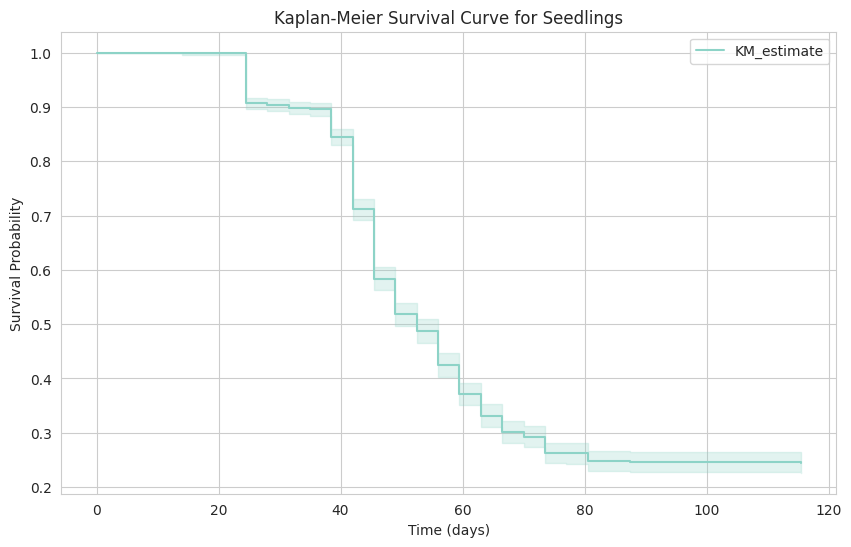

In [69]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

# 'Time' is the duration, 'Event' is the event occurrence (0 for censored, 1 for event)
kmf.fit(durations=df_final["Time"], event_observed=df_final["Event"])

plt.figure(figsize=(10, 6))
kmf.plot_survival_function()

plt.title("Kaplan-Meier Survival Curve for Seedlings")
plt.xlabel("Time (days)")
plt.ylabel("Survival Probability")
plt.grid(True)
plt.show()

# Task
Perform a log-rank test to compare the survival distributions of different groups based on 'Light_Cat' from the `Tree_Data.csv` dataset, and then fit a Cox Proportional Hazards model using the preprocessed features from the `df_final` DataFrame, including 'Time' and 'Event' columns, to assess the impact of various covariates on seedling survival time.

## Log-Rank Test

A log-rank test to compare the survival distributions of different groups based on a categorical variable (e.g., 'Light_Cat'). This will help determine if there are significant differences in survival probability between these groups.


In [70]:
from lifelines.statistics import logrank_test

# Identify groups for comparison based on one-hot encoded Light_Cat columns
# 'Light_Cat_Low' == True corresponds to 'Low' light
# 'Light_Cat_High' == True corresponds to 'Med' light

df_low_light = df_final[df_final["Light_Cat_Low"]]
df_high_light = df_final[df_final["Light_Cat_High"]]

# Perform Log-Rank Test between 'Low' and 'High' light categories
results = logrank_test(
    durations_A=df_low_light["Time"],
    event_observed_A=df_low_light["Event"],
    durations_B=df_high_light["Time"],
    event_observed_B=df_high_light["Event"],
)

print("Log-Rank Test Results (Low vs. High Light):")
results.print_summary()

Log-Rank Test Results (Low vs. High Light):


*   While the log-rank test for 'Light\_Cat' did not show significant differences, exploring other aspects of light, such as light intensity or duration, or using light as a continuous variable in the Cox model might reveal more nuanced effects.


## Training


### Train/Test data split

In [ ]:
from sklearn.model_selection import train_test_split

test_size = 0.2

# change from datetime to numeric (days since earliest PlantDate)
# Otherwise the lifelines model won't work
df_final["PlantDate"] = (df_final["PlantDate"] - df_final["PlantDate"].min()).dt.days

# 8. Separate the features (all columns except 'Time' and 'Event') into a DataFrame X
# and the target variables ('Time' and 'Event') into a DataFrame y.
X = df_final.drop(columns=["Time", "Event"])
y = df_final[["Time", "Event"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_size, random_state=42
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2225, 69)
Shape of X_test: (557, 69)
Shape of y_train: (2225, 2)
Shape of y_test: (557, 2)


### Fit Cox Proportional Hazards Model

Fit a Cox Proportional Hazards model using the `lifelines` library on the *training* data.
This model will assess the impact of various covariates (all remaining features) on seedling survival time, incorporating elastic-net regularization to handle multicollinearity and improve model stability.

In [ ]:
from lifelines import CoxPHFitter

# 2. Concatenate the training features (X_train) and training target variables (y_train) into a single DataFrame.
train_df = pd.concat([X_train, y_train], axis=1)

# 3. Instantiate a CoxPHFitter object with l1_ratio=0.1 and penalizer=0.01
cph = CoxPHFitter(l1_ratio=0.1, penalizer=0.01)

# 4. Fit the Cox Proportional Hazards model to the combined training DataFrame
cph.fit(train_df, duration_col="Time", event_col="Event")

print("Cox Proportional Hazards Model Summary:")
cph.print_summary()

Cox Proportional Hazards Model Summary:


<lifelines.CoxPHFitter: fitted with 2225 total observations, 961 right-censored observations>
             duration col = 'Time'
                event col = 'Event'
                penalizer = 0.01
                 l1 ratio = 0.1
      baseline estimation = breslow
   number of observations = 2225
number of events observed = 1264
   partial log-likelihood = -6425.48
         time fit was run = 2026-03-14 22:22:37 UTC

---
                            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                   
No                          0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Plot                        0.00      1.00      0.03           -0.06            0.06                0.95                1.06
Light_ISF                   0.84      2.32      1.94           -2.97            4.65                0.05              104.68
Core                        0.03      1.03      0.07           -0.11            0.17                0.90                1.18
PlantDate                   0.05      1.05      0.01            0.03            0.06                1.03                1.07
AMF                         0.00      1.00      0.00           -0.00            0.01                1.00                1.01
EMF                        -0.00      1.00      0.01           -0.01            0.01                0.99                1.01
Phenolics                  -0.01      0.99      0.07           -0.15            0.14                0.86                1.15
Lignin                     -0.01      0.99      0.02           -0.04            0.02                0.96                1.02
NSC                        -0.00      1.00      0.02           -0.03            0.03                0.97                1.03
Census                     -0.69      0.50      0.02           -0.72           -0.66                0.49                0.52
Harvest                    -3.80      0.02      0.24           -4.27           -3.32                0.01                0.04
Alive                      -0.81      0.44      0.47           -1.74            0.12                0.18                1.12
Subplot_D                  -0.01      0.99      0.07           -0.15            0.13                0.86                1.14
Subplot_A                   0.01      1.01      0.07           -0.13            0.15                0.88                1.16
Subplot_B                   0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Subplot_E                   0.01      1.01      0.15           -0.29            0.31                0.75                1.36
Species_Quercus alba       -0.01      0.99      0.34           -0.67            0.66                0.51                1.93
Species_Quercus rubra      -0.10      0.91      0.32           -0.73            0.54                0.48                1.71
Species_Prunus serotina     0.00      1.00      0.13           -0.25            0.26                0.78                1.29
Light_Cat_Low              -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
Light_Cat_High             -0.07      0.93      0.16           -0.38            0.23                0.68                1.26
Soil_Quercus rubra         -0.00      1.00      0.01           -0.01            0.01                0.99                1.01
Soil_Acer rubrum           -0.10      0.91      0.18           -0.45            0.25                0.64                1.29
Soil_Populus grandidentata -0.00      1.00      0.01           -0.02            0.02                0.98                1.02
Soil_Sterile               -0.02      0.98      0.54           -1.08            1.04                0.34                2.83
Soil_Acer saccharum        -0.05      0.95      0.16           -0.36      

### Evaluate Model on Test Data: C-Index and Integrated Brier Score (IBS)

In [81]:
from lifelines.utils import concordance_index

# Calculate C-Index on the training set
c_index_train = cph.score(train_df, scoring_method="concordance_index")
print(f"C-Index on training data: {c_index_train:.4f}")

test_df = pd.concat([X_test, y_test], axis=1)  # Combine X_test and y_test for scoring

c_index_test = cph.score(test_df, scoring_method="concordance_index")
print(f"C-Index on test data: {c_index_test:.4f}")

C-Index on training data: 0.9962
C-Index on test data: 0.9951
